# Projekt — Wykrywanie oszustw finansowych

Dane: Credit Card Fraud Detection https://www.kaggle.com/datasets/miadul/credit-card-fraud-detection-dataset

Cel biznesowy: Rozwój modeli do identyfikowania podejrzanych transakcji finansowych i zapobiegania oszustwom.

Stakeholderzy: Dział finansowy, ryzyka, bezpieczeństwa, klienci banku.

Nazwa teamu: **Ocean's Four**

| Kolumna | Opis |
|---|---|
| `transaction_id` | identyfikator transakcji |
| `amount` | kwota transakcji |
| `transaction_hour` | godzina transakcji (0–23) |
| `merchant_category` | kategoria sprzedawcy |
| `foreign_transaction` | czy transakcja zagraniczna (0/1) |
| `location_mismatch` | czy lokalizacja niezgodna z profilem klienta (0/1) |
| `device_trust_score` | ocena zaufania urządzenia (0–100) |
| `velocity_last_24h` | liczba transakcji w ostatnich 24 h |
| `cardholder_age` | wiek posiadacza karty |
| `is_fraud` | **zmienna celu**: 1 = oszustwo |

## 1. Zaimportowanie bibliotek

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, FunctionTransformer)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             precision_recall_curve, brier_score_loss,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
os.makedirs("data/processed", exist_ok=True)

## 2. Wczytanie bazy danych

In [2]:
df = pd.read_csv("data/credit_card_fraud_10k.csv")

## 3. Wstępne sprawdzenie danych

In [3]:
df.shape

(10000, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 851.2 KB


In [5]:
df.head(20)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0
8,9,165.43,8,Grocery,0,0,80,0,21,0
9,10,221.63,5,Grocery,0,0,59,1,34,0


In [6]:
if df.isnull().sum().sum() == 0:
    print("Brak wartości NULL w zbiorze danych.")
else:
    print("W zbiorze występują braki danych.")

Brak wartości NULL w zbiorze danych.


In [7]:
df = df.drop_duplicates()

In [8]:
df = df.drop(columns=["transaction_id"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   amount               10000 non-null  float64
 1   transaction_hour     10000 non-null  int64  
 2   merchant_category    10000 non-null  str    
 3   foreign_transaction  10000 non-null  int64  
 4   location_mismatch    10000 non-null  int64  
 5   device_trust_score   10000 non-null  int64  
 6   velocity_last_24h    10000 non-null  int64  
 7   cardholder_age       10000 non-null  int64  
 8   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 773.1 KB


In [9]:
df.describe()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


## 4. WIZUALIZACJE — graficzne pokazanie danych

### 4.1. Rozkład transakcji fraudowych i poprawnych

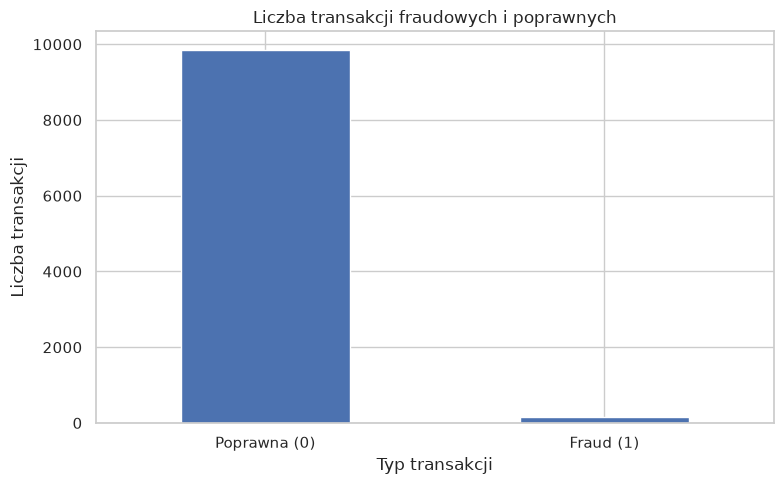

Udział fraudów: 1.51%


In [10]:
fraud_counts = df["is_fraud"].value_counts()

plt.figure(figsize=(8,5))
fraud_counts.plot(kind="bar")

plt.title("Liczba transakcji fraudowych i poprawnych")
plt.xlabel("Typ transakcji")
plt.ylabel("Liczba transakcji")

plt.xticks([0,1], ["Poprawna (0)", "Fraud (1)"], rotation=0)

plt.tight_layout()
plt.show()

print(f"Udział fraudów: {df['is_fraud'].mean():.2%}")

Tylko **1,5%** transakcji to oszustwa — to kluczowa cecha problemu.
Wniosek dla modelowania: accuracy jest bezużyteczne (model zawsze przewidujący
„brak fraudu" miałby 98,5% accuracy), trzeba używać metryk precision/recall/PR-AUC
oraz ważenia klas.

### 4.2. Kwota transakcji a występowanie fraudu (Boxplot)

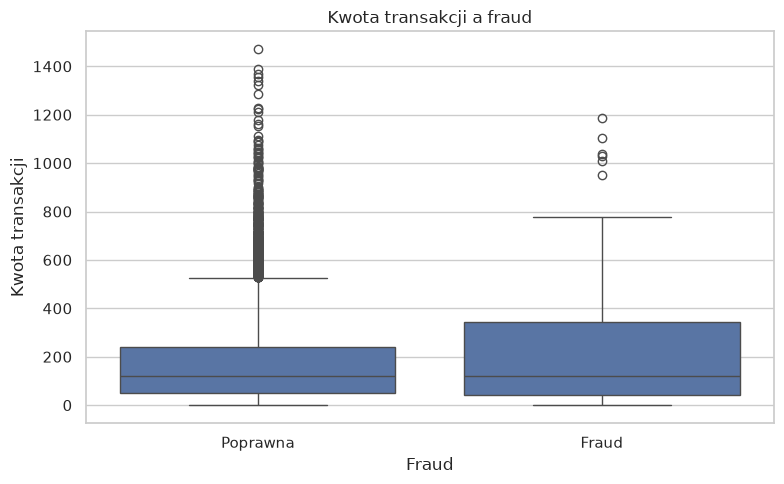

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount"
)

plt.title("Kwota transakcji a fraud")
plt.xlabel("Fraud")
plt.ylabel("Kwota transakcji")

plt.xticks([0,1], ["Poprawna", "Fraud"])

plt.tight_layout()
plt.show()

Interpretacja

Średnia wartość transakcji:

Poprawne: 175.33
Fraudowe: 216.18

Wnioski:

Fraudowe transakcje są przeciętnie droższe.
Sama kwota nie wystarczy do identyfikacji fraudu, ale może być istotną cechą modelu.

### 4.3. Fraud rate dla transakcji zagranicznych

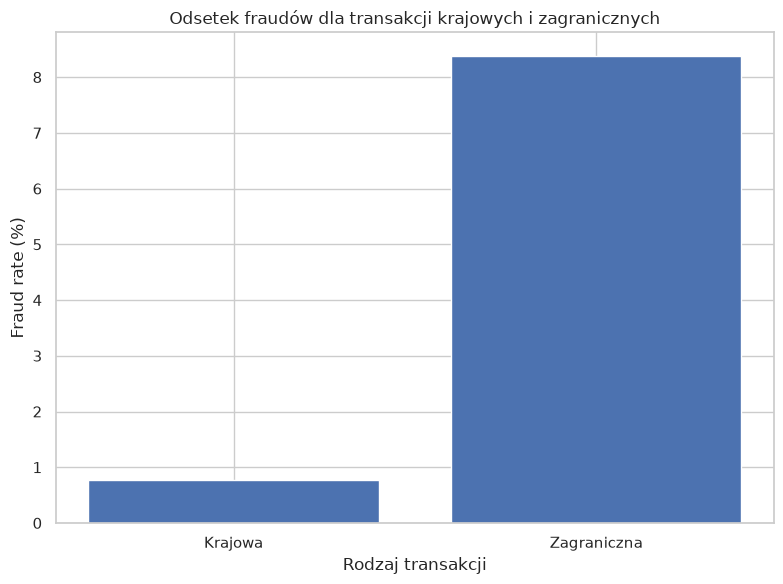

,foreign_transaction,is_fraud
0,0,0.007648
1,1,0.083845


In [12]:
fraud_rate = (
    df.groupby("foreign_transaction")["is_fraud"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,6))
plt.bar(
    ["Krajowa", "Zagraniczna"],
    fraud_rate["is_fraud"] * 100
)

plt.title("Odsetek fraudów dla transakcji krajowych i zagranicznych")
plt.xlabel("Rodzaj transakcji")
plt.ylabel("Fraud rate (%)")

plt.tight_layout()
plt.show()

fraud_rate

Transakcje zagraniczne są ponad 10 razy bardziej narażone na fraud niż krajowe. Jest to jedna z najsilniejszych zależności w zbiorze.

### 4.4. Heatmapa korelacji zmiennych numerycznych

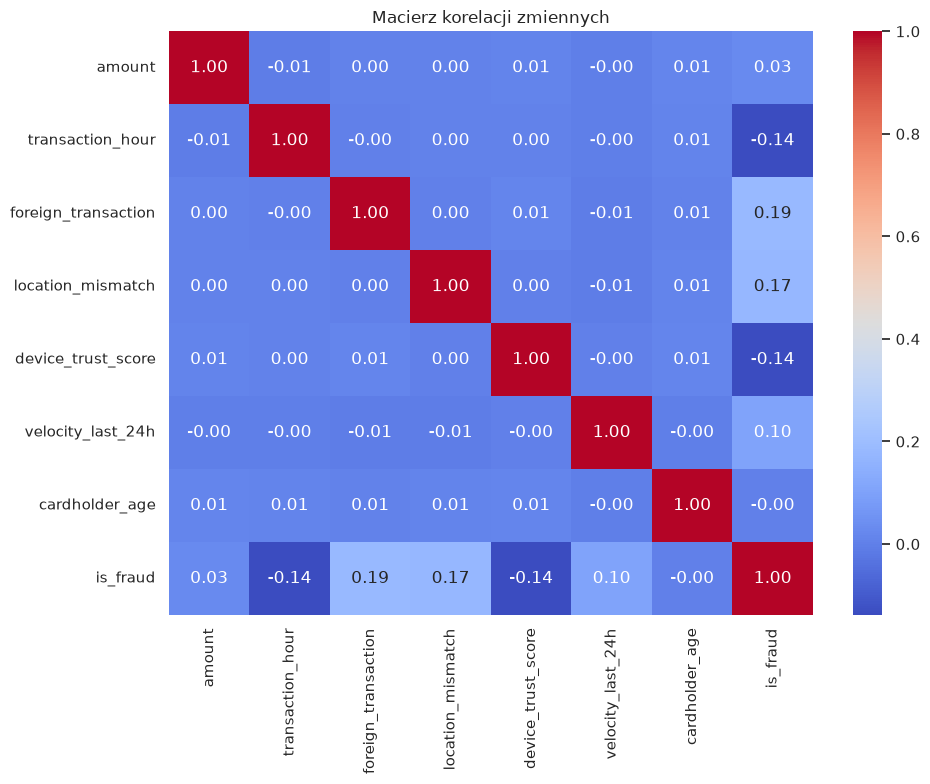

Korelacja cech z is_fraud (malejąco wg wartości bezwzględnej):
foreign_transaction    0.186
location_mismatch      0.173
transaction_hour      -0.139
device_trust_score    -0.138
velocity_last_24h      0.103
amount                 0.028
cardholder_age        -0.001
Name: is_fraud, dtype: float64


In [13]:
numeric_cols = [
    "amount",
    "transaction_hour",
    "foreign_transaction",
    "location_mismatch",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age",
    "is_fraud"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Macierz korelacji zmiennych")

plt.tight_layout()
plt.show()

print("Korelacja cech z is_fraud (malejąco wg wartości bezwzględnej):")
print(corr["is_fraud"].drop("is_fraud").reindex(
    corr["is_fraud"].drop("is_fraud").abs().sort_values(ascending=False).index).round(3))

Wnioski:

Fraudy częściej pojawiają się:
przy dużej liczbie transakcji w ciągu 24h,
przy niezgodności lokalizacji,
przy transakcjach zagranicznych.

Fraudy rzadziej występują dla urządzeń o wysokim poziomie zaufania.

### 4.5. Rozkłady zmiennych liczbowych

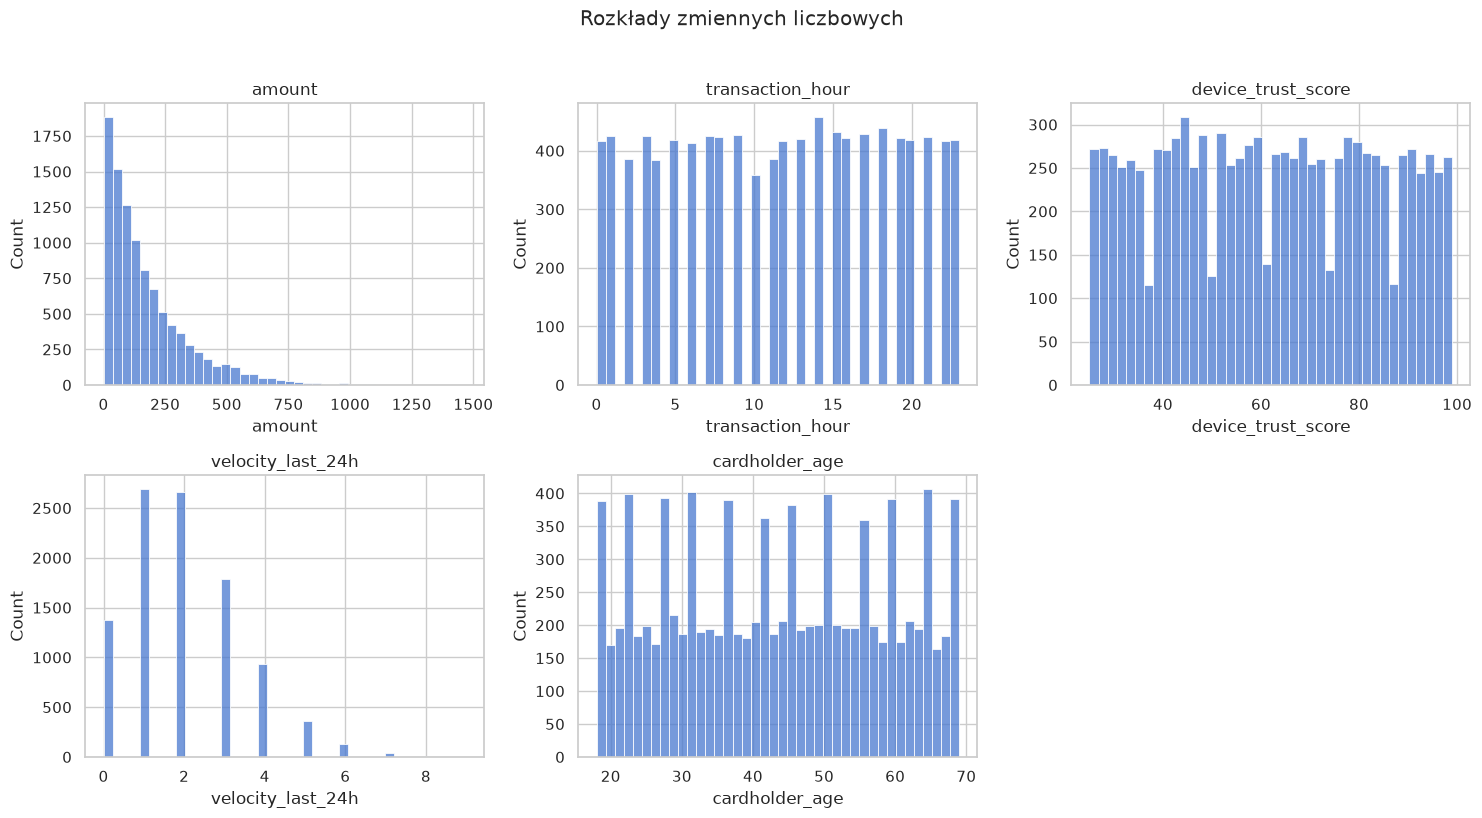

In [14]:
num_cols = ["amount", "transaction_hour", "device_trust_score",
            "velocity_last_24h", "cardholder_age"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], bins=40, ax=ax, color="#4878CF")
    ax.set_title(col)
axes.flat[-1].axis("off")
fig.suptitle("Rozkłady zmiennych liczbowych", y=1.02)
plt.tight_layout()
plt.show()

### 4.6. Częstość oszustw wg kategorii sprzedawcy, godziny i lokalizacji

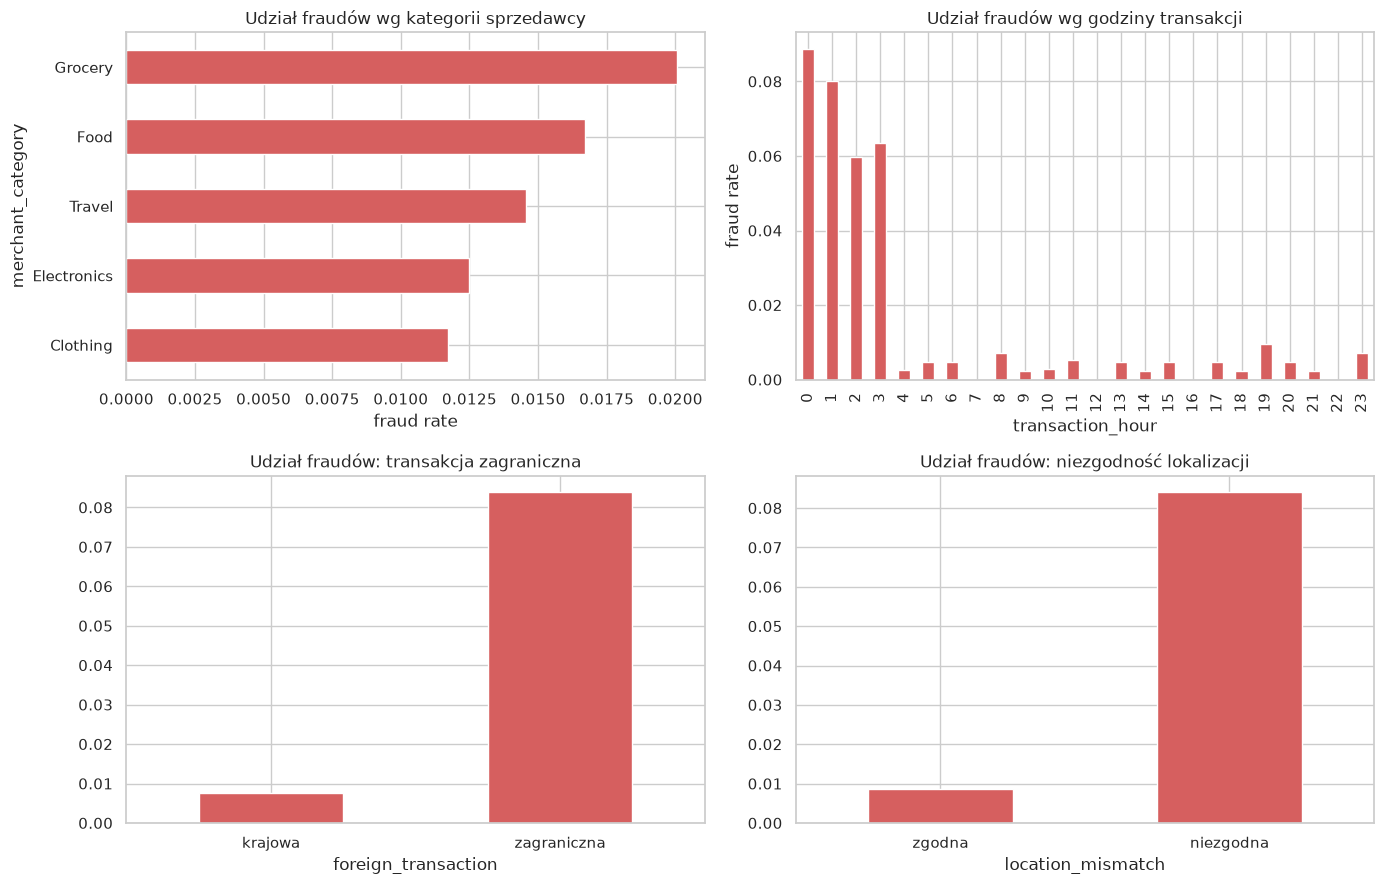

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

df.groupby("merchant_category")["is_fraud"].mean().sort_values().plot(
    kind="barh", ax=axes[0, 0], color="#D65F5F")
axes[0, 0].set_title("Udział fraudów wg kategorii sprzedawcy")
axes[0, 0].set_xlabel("fraud rate")

df.groupby("transaction_hour")["is_fraud"].mean().plot(
    kind="bar", ax=axes[0, 1], color="#D65F5F")
axes[0, 1].set_title("Udział fraudów wg godziny transakcji")
axes[0, 1].set_ylabel("fraud rate")

df.groupby("foreign_transaction")["is_fraud"].mean().plot(
    kind="bar", ax=axes[1, 0], color="#D65F5F")
axes[1, 0].set_title("Udział fraudów: transakcja zagraniczna")
axes[1, 0].set_xticklabels(["krajowa", "zagraniczna"], rotation=0)

df.groupby("location_mismatch")["is_fraud"].mean().plot(
    kind="bar", ax=axes[1, 1], color="#D65F5F")
axes[1, 1].set_title("Udział fraudów: niezgodność lokalizacji")
axes[1, 1].set_xticklabels(["zgodna", "niezgodna"], rotation=0)

plt.tight_layout()
plt.show()

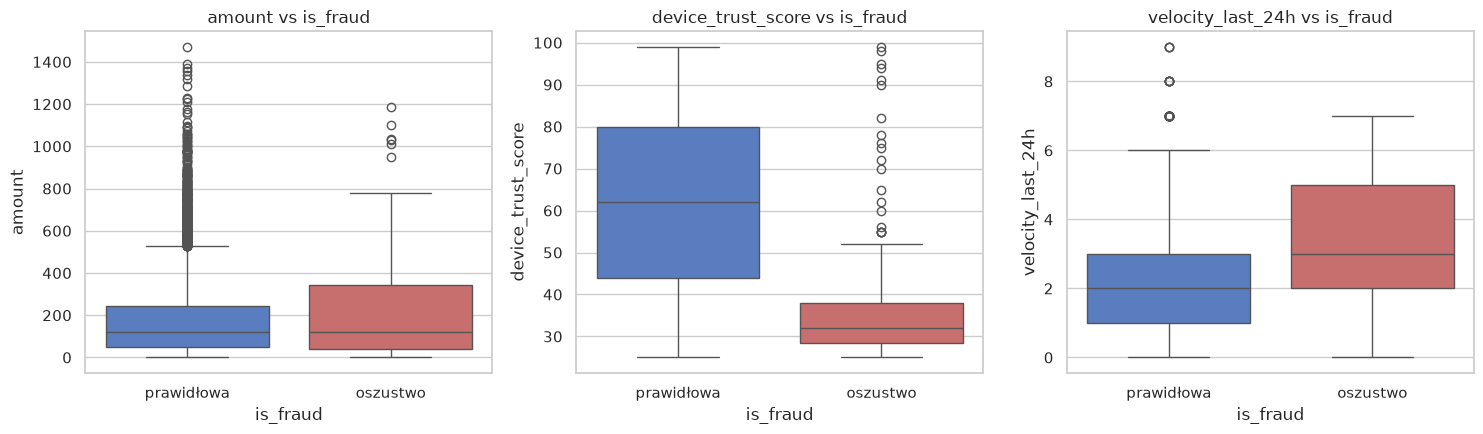

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["amount", "device_trust_score", "velocity_last_24h"]):
    sns.boxplot(data=df, x="is_fraud", y=col, hue="is_fraud",
                palette=["#4878CF", "#D65F5F"], legend=False, ax=ax)
    ax.set_title(f"{col} vs is_fraud")
    ax.set_xticklabels(["prawidłowa", "oszustwo"])
plt.tight_layout()
plt.show()

### 4.7. Wnioski z EDA

1. **Dane są czyste** — bez braków i duplikatów, nie wymagają imputacji;
   `transaction_id` (czysty identyfikator) został usunięty na etapie czyszczenia.
2. **Klasy silnie niezbalansowane (1,5% fraudów)** — w modelowaniu użyjemy
   `class_weight='balanced'` i metryk odpornych na niezbalansowanie (PR-AUC, recall).
3. Największy związek z fraudem wykazują (kierunki zgodne z intuicją):
   `location_mismatch`, `foreign_transaction`, `device_trust_score` (ujemnie),
   `velocity_last_24h` oraz `amount`; fraudy nasilają się w godzinach nocnych.
4. `merchant_category` różnicuje fraud rate umiarkowanie — zakodujemy ją one-hot
   i pozwolimy modelowi zdecydować o jej przydatności.

## 5. Przygotowanie danych do modelowania (Sprint 2)

| Zadanie z Jiry | Sekcja |
|---|---|
| DS24G2-11 Selekcja cech (Feature Selection) | 5.1 |
| DS24G2-12 Kodowanie zmiennej `merchant_category` | 5.2 |
| DS24G2-13 Transformacja zmiennej `transaction_hour` | 5.3 |
| DS24G2-14 Przygotowanie danych do procesu uczenia | 5.4 |
| DS24G2-15 Podział danych na zbiory treningowy i testowy | 5.5 |
| DS24G2-16 Trenowanie i strojenie modeli | 6 |
| DS24G2-17 Obsługa problemu niezbalansowanych danych | 6.1 |

### 5.1. Selekcja cech (DS24G2-11)

Oceniamy przydatność każdej cechy dwiema niezależnymi metodami:
korelacją z celem oraz **informacją wzajemną** (mutual information),
która wychwytuje też zależności nieliniowe.

In [17]:
features = df.drop(columns=["is_fraud"])
X_mi = pd.get_dummies(features, columns=["merchant_category"], drop_first=True)

corr_with_target = X_mi.corrwith(df["is_fraud"]).rename("korelacja")
mi = pd.Series(
    mutual_info_classif(X_mi, df["is_fraud"], random_state=RANDOM_STATE),
    index=X_mi.columns, name="mutual_information")

ranking = pd.concat([corr_with_target, mi], axis=1)
ranking = ranking.reindex(mi.sort_values(ascending=False).index).round(4)
ranking

,korelacja,mutual_information
device_trust_score,-0.1379,0.0139
transaction_hour,-0.1387,0.0138
foreign_transaction,0.1856,0.0100
location_mismatch,0.1730,0.0089
velocity_last_24h,0.1034,0.0067
merchant_category_Grocery,0.0200,0.0012
merchant_category_Electronics,-0.0105,0.0002
amount,0.0284,0.0000
cardholder_age,-0.0006,0.0000
merchant_category_Food,0.0068,0.0000


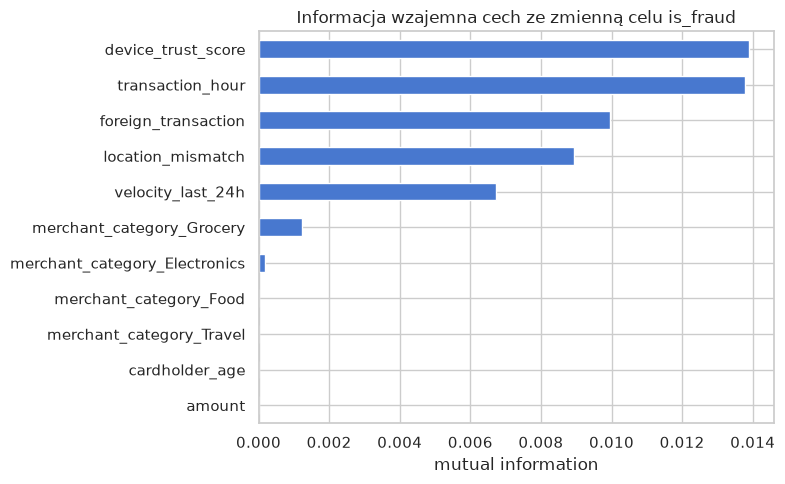

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
mi.sort_values().plot(kind="barh", ax=ax, color="#4878CF")
ax.set_title("Informacja wzajemna cech ze zmienną celu is_fraud")
ax.set_xlabel("mutual information")
plt.tight_layout()
plt.show()

**Decyzja o selekcji cech:** `transaction_id` został już usunięty (identyfikator,
zero wartości predykcyjnej). **Pozostałe cechy zostawiamy wszystkie** — największy
sygnał niosą `device_trust_score`, `location_mismatch`, `foreign_transaction`,
`velocity_last_24h` i `amount`; słabsze (`cardholder_age`, kategorie sprzedawcy)
zostają, bo zbiór jest mały, a ostateczną weryfikacją będzie ważność cech w sekcji 6.

### 5.2. Kodowanie zmiennej `merchant_category` (DS24G2-12)

Zmienna nominalna bez naturalnego porządku (5 kategorii o zbliżonej liczności)
→ **one-hot encoding** z `drop='first'`, żeby uniknąć współliniowości w regresji
logistycznej. W finalnym pipelinie używamy `OneHotEncoder` ze scikit-learn
(a nie `pd.get_dummies`), bo enkoder zapamiętuje kategorie ze zbioru treningowego
i identycznie koduje nowe dane.

In [19]:
enc = OneHotEncoder(drop="first", sparse_output=False)
encoded = enc.fit_transform(df[["merchant_category"]])
encoded_df = pd.DataFrame(encoded, columns=enc.get_feature_names_out())

print("Kategorie:", list(enc.categories_[0]))
print("Kolumny po zakodowaniu (drop='first' usuwa pierwszą alfabetycznie — Clothing):")
encoded_df.head()

Kategorie: ['Clothing', 'Electronics', 'Food', 'Grocery', 'Travel']
Kolumny po zakodowaniu (drop='first' usuwa pierwszą alfabetycznie — Clothing):


,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0


### 5.3. Transformacja zmiennej `transaction_hour` (DS24G2-13)

Godzina jest zmienną **cykliczną**: 23:00 i 0:00 dzieli godzina, a nie 23.
Traktowanie jej jako zwykłej liczby zaburza tę geometrię, dlatego kodujemy ją
na okręgu parą wartości sin/cos:

$$hour\_sin = \sin\left(\frac{2\pi h}{24}\right), \qquad
hour\_cos = \cos\left(\frac{2\pi h}{24}\right)$$

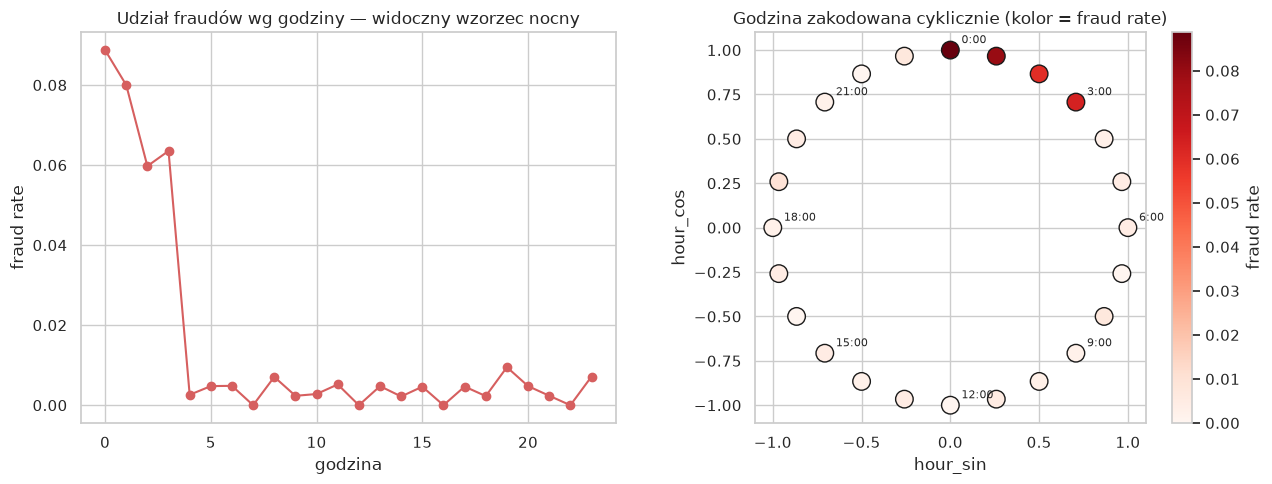

In [20]:
hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)
fraud_by_hour = df.groupby("transaction_hour")["is_fraud"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(fraud_by_hour.index, fraud_by_hour.values, "o-", color="#D65F5F")
ax1.set_xlabel("godzina"); ax1.set_ylabel("fraud rate")
ax1.set_title("Udział fraudów wg godziny — widoczny wzorzec nocny")

sc = ax2.scatter(hour_sin, hour_cos, c=fraud_by_hour.reindex(hours).values,
                 cmap="Reds", s=160, edgecolor="k")
for h in hours[::3]:
    ax2.annotate(f"{h}:00", (hour_sin[h], hour_cos[h]),
                 textcoords="offset points", xytext=(8, 5), fontsize=8)
ax2.set_xlabel("hour_sin"); ax2.set_ylabel("hour_cos")
ax2.set_title("Godzina zakodowana cyklicznie (kolor = fraud rate)")
ax2.set_aspect("equal")
plt.colorbar(sc, ax=ax2, label="fraud rate")

plt.tight_layout()
plt.show()

Fraud rate jest wyraźnie podwyższony w godzinach nocnych (ok. 0–5), a kodowanie
sin/cos ustawia te godziny obok siebie na okręgu — model liniowy może nauczyć się
„nocności" transakcji jako prostego kierunku w przestrzeni cech.

### 5.4. Przygotowanie danych do procesu uczenia (DS24G2-14)

Składamy wszystkie kroki w jeden `ColumnTransformer`:
- `merchant_category` → one-hot (`drop='first'`),
- `transaction_hour` → sin/cos (`FunctionTransformer`),
- pozostałe cechy liczbowe → standaryzacja (`StandardScaler`).

Transformer jest **uczony wyłącznie na zbiorze treningowym** (wewnątrz pipeline'u
w sekcji 6), co eliminuje wyciek danych (data leakage).

In [21]:
def hour_to_sin_cos(X):
    h = np.asarray(X, dtype=float)
    return np.column_stack([np.sin(2 * np.pi * h[:, 0] / 24),
                            np.cos(2 * np.pi * h[:, 0] / 24)])

CAT_COLS = ["merchant_category"]
HOUR_COL = ["transaction_hour"]
NUM_COLS = ["amount", "foreign_transaction", "location_mismatch",
            "device_trust_score", "velocity_last_24h", "cardholder_age"]

def make_preprocess():
    return ColumnTransformer([
        ("cat", OneHotEncoder(drop="first"), CAT_COLS),
        ("hour", FunctionTransformer(
            hour_to_sin_cos,
            feature_names_out=lambda t, names: ["hour_sin", "hour_cos"]), HOUR_COL),
        ("num", StandardScaler(), NUM_COLS),
    ])

preprocess = make_preprocess()
sample = preprocess.fit_transform(df.drop(columns=["is_fraud"]))
pd.DataFrame(sample, columns=preprocess.get_feature_names_out()).head()

,cat__merchant_category_Electronics,cat__merchant_category_Food,cat__merchant_category_Grocery,cat__merchant_category_Travel,hour__hour_sin,hour__hour_cos,num__amount,num__foreign_transaction,num__location_mismatch,num__device_trust_score,num__velocity_last_24h,num__cardholder_age
0,1.0,0.0,0.0,0.0,-0.500000,0.866025,-0.521597,-0.329244,-0.306158,0.195528,0.691873,-0.231580
1,0.0,0.0,0.0,1.0,0.707107,0.707107,2.086108,3.037260,-0.306158,1.172909,-0.704299,1.370727
2,0.0,0.0,1.0,0.0,-0.965926,-0.258819,0.348151,-0.329244,-0.306158,-0.595686,-0.704299,1.170439
3,0.0,0.0,1.0,0.0,0.866025,0.500000,-0.066254,-0.329244,3.266284,0.474779,0.691873,-0.632157
4,0.0,1.0,0.0,0.0,-0.707107,-0.707107,-0.829151,-0.329244,-0.306158,0.800573,-1.402386,0.035471


### 5.5. Podział na zbiory treningowy i testowy (DS24G2-15)

Podział 75/25 ze **stratyfikacją** po `is_fraud` — przy 1,5% fraudów zwykły losowy
podział mógłby zostawić w teście za mało (albo za dużo) przypadków pozytywnych.
Przetworzone zbiory zapisujemy do `data/processed/` (katalog w `.gitignore` —
pliki pozostają lokalnymi artefaktami).

In [22]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

X_train.assign(is_fraud=y_train).to_csv("data/processed/train.csv", index=False)
X_test.assign(is_fraud=y_test).to_csv("data/processed/test.csv", index=False)

summary = pd.DataFrame({
    "wiersze": [len(X_train), len(X_test)],
    "fraudy": [y_train.sum(), y_test.sum()],
    "fraud rate": [f"{y_train.mean():.3%}", f"{y_test.mean():.3%}"],
}, index=["train", "test"])
summary

,wiersze,fraudy,fraud rate
train,7500,113,1.507%
test,2500,38,1.520%


## 6. Trenowanie i strojenie modeli (Sprint 2 i 3)

| Zadanie z Jiry | Sekcja |
|---|---|
| *Sprint 2:* DS24G2-17 Obsługa problemu niezbalansowanych danych | 6.1 |
| *Sprint 2:* DS24G2-16 Trenowanie i strojenie modeli | 6.2 |
| *Sprint 3:* Strojenie hiperparametrów z walidacją krzyżową | 6.2 |
| *Sprint 3:* Ewaluacja metrykami dla klas niezbalansowanych | 6.3 |
| *Sprint 3:* Macierze pomyłek oraz krzywe ROC i precision-recall | 6.3 |
| *Sprint 3:* Dobór progu decyzyjnego | 6.4 i 6.8 |
| *Sprint 3:* Analiza ważności cech i interpretacja modelu | 6.5 |
| *Sprint 3 (nadprogram):* porównanie z XGBoost, kalibracja prawdopodobieństw | 6.6–6.7 |

Plan:
1. **DS24G2-17**: porównanie strategii obsługi niezbalansowania
   (bez obsługi / `class_weight='balanced'` / undersampling),
2. **DS24G2-16**: strojenie hiperparametrów (`GridSearchCV`, 5-krotna stratyfikowana
   walidacja krzyżowa, metryka `average_precision`),
3. ewaluacja końcowa: metryki, macierze pomyłek, krzywe ROC/PR,
4. dobór progu decyzyjnego i ważność cech, wnioski.

In [23]:
def evaluate(name, pipe, Xte=None, yte=None):
    Xte = X_test if Xte is None else Xte
    yte = y_test if yte is None else yte
    proba = pipe.predict_proba(Xte)[:, 1]
    pred = pipe.predict(Xte)
    return {"model": name,
            "recall": recall_score(yte, pred),
            "precision": precision_score(yte, pred, zero_division=0),
            "F1": f1_score(yte, pred),
            "ROC-AUC": roc_auc_score(yte, proba),
            "PR-AUC": average_precision_score(yte, proba)}

print(f"train: {X_train.shape}, test: {X_test.shape}, "
      f"fraud rate train/test: {y_train.mean():.3%} / {y_test.mean():.3%}")

train: (7500, 8), test: (2500, 8), fraud rate train/test: 1.507% / 1.520%


### 6.1. Obsługa niezbalansowanych danych (DS24G2-17)

Fraudy to 1,5% zbioru. Porównujemy trzy strategie dla obu modeli:

1. **bez obsługi** — model uczony na surowym rozkładzie klas,
2. **`class_weight='balanced'`** — błędy na klasie mniejszościowej ważone
   odwrotnością jej częstości,
3. **random undersampling 1:1** — losowe zredukowanie klasy większościowej
   w zbiorze treningowym do liczności fraudów (test pozostaje nietknięty!).

In [24]:
# undersampling wykonujemy wyłącznie na zbiorze treningowym
train = X_train.assign(is_fraud=y_train)
fraud = train[train.is_fraud == 1]
legit = train[train.is_fraud == 0].sample(n=len(fraud), random_state=RANDOM_STATE)
under = pd.concat([fraud, legit]).sample(frac=1, random_state=RANDOM_STATE)
X_under, y_under = under.drop(columns="is_fraud"), under["is_fraud"]
print(f"zbiór po undersamplingu: {len(under)} wierszy "
      f"(fraud rate: {y_under.mean():.0%})")

imbalance_results = []
for model_name, factory in {
    "Regresja logistyczna": lambda **kw: LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, **kw),
    "Las losowy": lambda **kw: RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2, n_jobs=-1,
        random_state=RANDOM_STATE, **kw),
}.items():
    for strategy, kwargs, (Xtr, ytr) in [
        ("bez obsługi", {}, (X_train, y_train)),
        ("class_weight='balanced'", {"class_weight": "balanced"}, (X_train, y_train)),
        ("undersampling 1:1", {}, (X_under, y_under)),
    ]:
        pipe = Pipeline([("prep", make_preprocess()), ("model", factory(**kwargs))])
        pipe.fit(Xtr, ytr)
        row = evaluate(f"{model_name} — {strategy}", pipe)
        imbalance_results.append(row)

imbalance_df = pd.DataFrame(imbalance_results).set_index("model").round(3)
imbalance_df

zbiór po undersamplingu: 226 wierszy (fraud rate: 50%)


,recall,precision,F1,ROC-AUC,PR-AUC
model,,,,,
Regresja logistyczna — bez obsługi,0.579,0.733,0.647,0.994,0.738
Regresja logistyczna — class_weight='balanced',1.000,0.250,0.400,0.994,0.680
Regresja logistyczna — undersampling 1:1,0.974,0.181,0.306,0.992,0.661
Las losowy — bez obsługi,0.421,1.000,0.593,0.999,0.973
Las losowy — class_weight='balanced',0.921,1.000,0.959,1.000,0.991
Las losowy — undersampling 1:1,1.000,0.129,0.228,0.999,0.948


**Wnioski (DS24G2-17):** bez obsługi niezbalansowania regresja logistyczna ma
niski recall (przepuszcza dużą część fraudów) mimo dobrej precyzji. Ważenie klas
i undersampling znacząco podnoszą recall kosztem precyzji; `class_weight='balanced'`
daje efekt zbliżony do undersamplingu **bez wyrzucania danych**, dlatego wybieramy
tę strategię do dalszego strojenia.

### 6.2. Strojenie hiperparametrów (DS24G2-16)

`GridSearchCV` z 5-krotną stratyfikowaną walidacją krzyżową na zbiorze treningowym;
metryka optymalizacji: **average precision (PR-AUC)** — właściwa przy silnym
niezbalansowaniu.

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "Regresja logistyczna": (
        LogisticRegression(class_weight="balanced", max_iter=2000,
                           random_state=RANDOM_STATE),
        {"model__C": [0.01, 0.1, 1, 10, 100]},
    ),
    "Las losowy": (
        RandomForestClassifier(class_weight="balanced", n_jobs=-1,
                               random_state=RANDOM_STATE),
        {"model__n_estimators": [200, 400],
         "model__max_depth": [None, 6, 10],
         "model__min_samples_leaf": [1, 2, 5]},
    ),
}

searches = {}
for name, (est, grid) in param_grids.items():
    gs = GridSearchCV(
        Pipeline([("prep", make_preprocess()), ("model", est)]),
        grid, scoring="average_precision", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    searches[name] = gs
    print(f"{name}:")
    print(f"  najlepsze parametry: {gs.best_params_}")
    print(f"  średni PR-AUC (CV):  {gs.best_score_:.4f}\n")

Regresja logistyczna:
  najlepsze parametry: {'model__C': 10}
  średni PR-AUC (CV):  0.6353



Las losowy:
  najlepsze parametry: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 400}
  średni PR-AUC (CV):  0.9607



### 6.3. Ewaluacja końcowa na zbiorze testowym

In [26]:
pipelines = {
    "Baseline (dummy)": Pipeline([
        ("prep", make_preprocess()),
        ("model", DummyClassifier(strategy="stratified",
                                  random_state=RANDOM_STATE))]).fit(X_train, y_train),
    "Regresja logistyczna (tuned)": searches["Regresja logistyczna"].best_estimator_,
    "Las losowy (tuned)": searches["Las losowy"].best_estimator_,
}

probas = {name: pipe.predict_proba(X_test)[:, 1] for name, pipe in pipelines.items()}
results_df = pd.DataFrame(
    [evaluate(name, pipe) for name, pipe in pipelines.items()]
).set_index("model").round(3)
results_df

,recall,precision,F1,ROC-AUC,PR-AUC
model,,,,,
Baseline (dummy),0.026,0.025,0.026,0.505,0.015
Regresja logistyczna (tuned),1.000,0.255,0.406,0.994,0.682
Las losowy (tuned),0.921,1.000,0.959,1.000,0.991


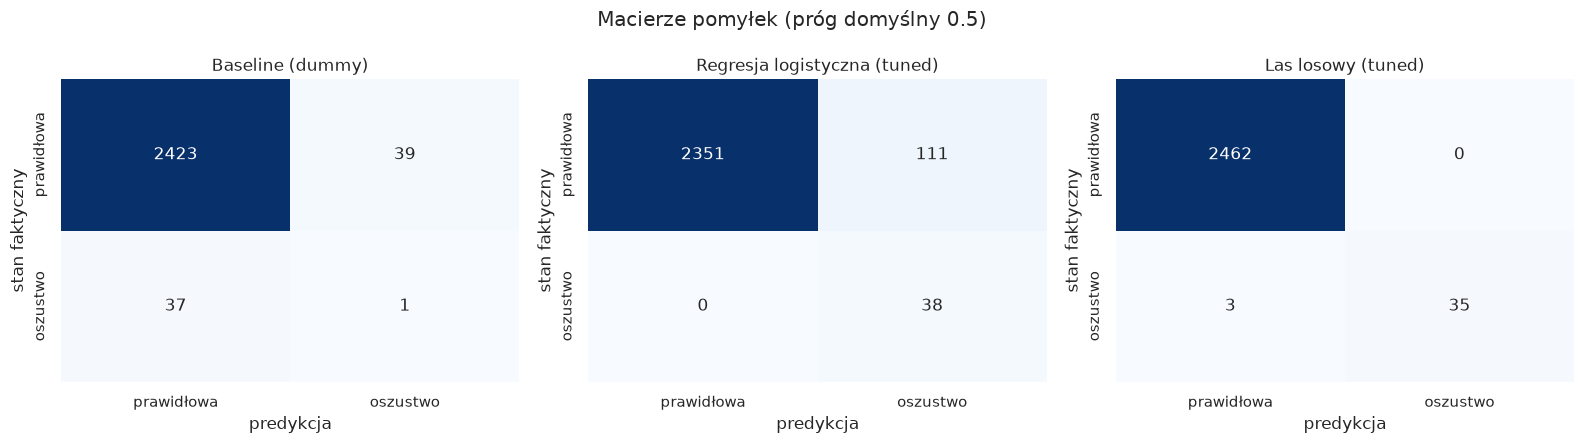

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax,
                xticklabels=["prawidłowa", "oszustwo"],
                yticklabels=["prawidłowa", "oszustwo"])
    ax.set_title(name)
    ax.set_xlabel("predykcja"); ax.set_ylabel("stan faktyczny")
plt.suptitle("Macierze pomyłek (próg domyślny 0.5)")
plt.tight_layout()
plt.show()

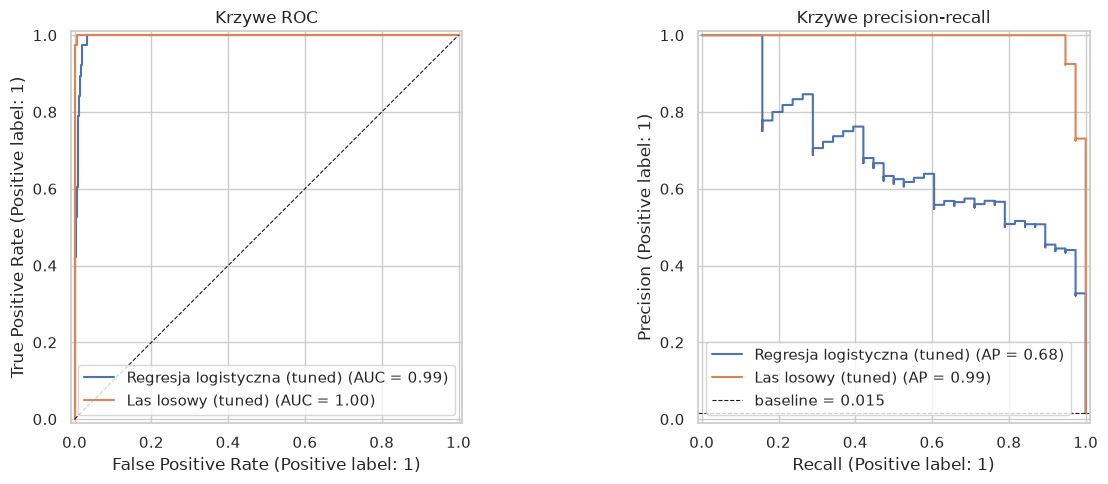

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for name in ["Regresja logistyczna (tuned)", "Las losowy (tuned)"]:
    RocCurveDisplay.from_predictions(y_test, probas[name], name=name, ax=ax1)
    PrecisionRecallDisplay.from_predictions(y_test, probas[name], name=name, ax=ax2)
ax1.plot([0, 1], [0, 1], "k--", lw=0.8)
ax1.set_title("Krzywe ROC")
ax2.axhline(y_test.mean(), color="k", ls="--", lw=0.8,
            label=f"baseline = {y_test.mean():.3f}")
ax2.set_title("Krzywe precision-recall")
ax2.legend()
plt.tight_layout()
plt.show()

### 6.4. Dobór progu decyzyjnego

W wykrywaniu fraudów koszt przeoczenia oszustwa (FN) jest zwykle dużo wyższy niż
koszt fałszywego alarmu (FP), a domyślny próg 0,5 nie musi być optymalny.
Przeszukujemy progi z krzywej precision-recall i wybieramy ten, który
**maksymalizuje F1**; krzywa pokazuje pełny kompromis, gdyby biznes chciał
przesunąć próg w stronę wyższego recallu.

In [29]:
best_name = results_df["PR-AUC"].idxmax()
best_proba = probas[best_name]
print(f"Najlepszy model wg PR-AUC: {best_name}")

prec, rec, thr = precision_recall_curve(y_test, best_proba)
f1_scores = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
idx = np.argmax(f1_scores)
threshold = thr[idx]

pred_t = (best_proba >= threshold).astype(int)
print(f"Dobrany próg: {threshold:.3f}")
print(f"recall = {recall_score(y_test, pred_t):.3f}, "
      f"precision = {precision_score(y_test, pred_t):.3f}, "
      f"F1 = {f1_score(y_test, pred_t):.3f}")
print()
print(classification_report(y_test, pred_t,
      target_names=["prawidłowa", "oszustwo"]))

Najlepszy model wg PR-AUC: Las losowy (tuned)
Dobrany próg: 0.498
recall = 0.947, precision = 1.000, F1 = 0.973

              precision    recall  f1-score   support

  prawidłowa       1.00      1.00      1.00      2462
    oszustwo       1.00      0.95      0.97        38

    accuracy                           1.00      2500
   macro avg       1.00      0.97      0.99      2500
weighted avg       1.00      1.00      1.00      2500



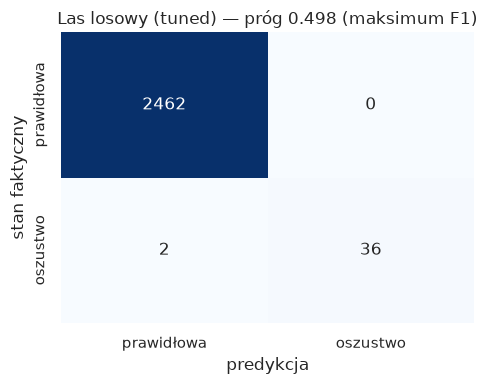

In [30]:
cm = confusion_matrix(y_test, pred_t)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax,
            xticklabels=["prawidłowa", "oszustwo"],
            yticklabels=["prawidłowa", "oszustwo"])
ax.set_title(f"{best_name} — próg {threshold:.3f} (maksimum F1)")
ax.set_xlabel("predykcja"); ax.set_ylabel("stan faktyczny")
plt.tight_layout()
plt.show()

### 6.5. Ważność cech

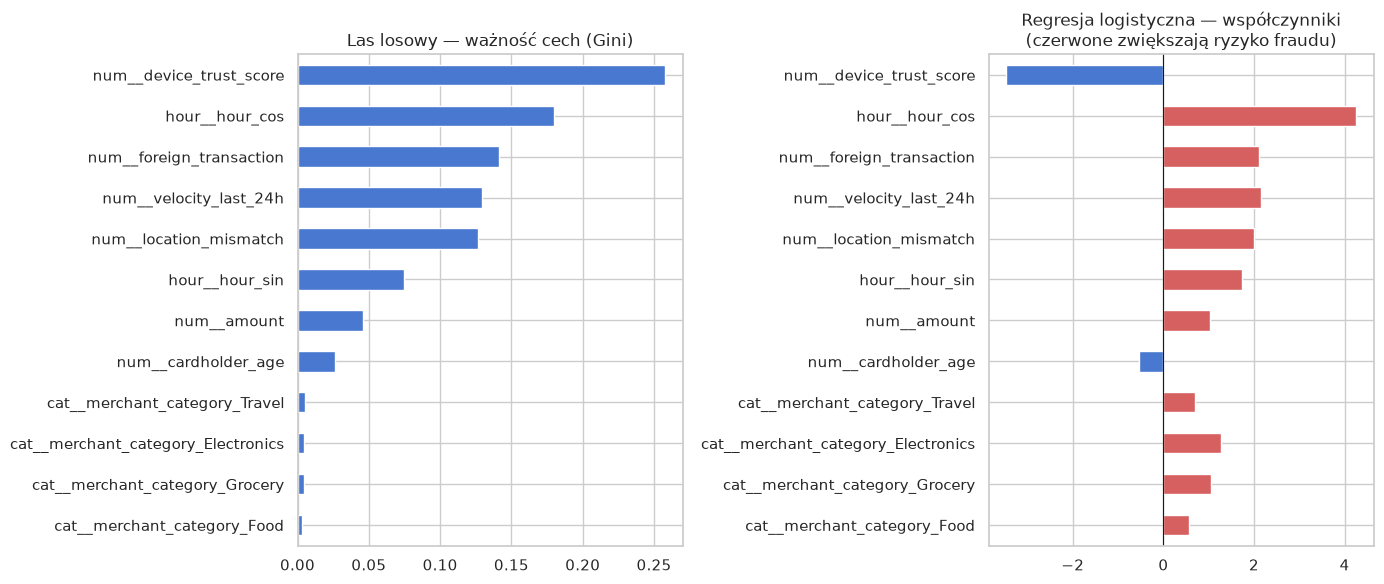

In [31]:
rf_pipe = pipelines["Las losowy (tuned)"]
feat_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_, index=feat_names
).sort_values()

lr_pipe = pipelines["Regresja logistyczna (tuned)"]
coefs = pd.Series(
    lr_pipe.named_steps["model"].coef_[0], index=feat_names
).reindex(importances.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
importances.plot(kind="barh", ax=ax1, color="#4878CF")
ax1.set_title("Las losowy — ważność cech (Gini)")
coefs.plot(kind="barh", ax=ax2,
           color=(coefs > 0).map({True: "#D65F5F", False: "#4878CF"}))
ax2.set_title("Regresja logistyczna — współczynniki\n(czerwone zwiększają ryzyko fraudu)")
ax2.axvline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()

### 6.6. Porównanie z gradient boostingiem (XGBoost)

Sprawdzamy, czy nowocześniejszy algorytm — **XGBoost** (gradient boosting) — pobije
strojony las losowy. Niezbalansowanie obsługujemy parametrem `scale_pos_weight`
(stosunek liczności klas), odpowiednikiem `class_weight='balanced'`.

In [32]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([
    ("prep", make_preprocess()),
    ("model", XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
        random_state=RANDOM_STATE, n_jobs=-1)),
])
xgb_pipe.fit(X_train, y_train)

pipelines["XGBoost"] = xgb_pipe
probas["XGBoost"] = xgb_pipe.predict_proba(X_test)[:, 1]

results_df = pd.concat([
    results_df,
    pd.DataFrame([evaluate("XGBoost", xgb_pipe)]).set_index("model").round(3),
])
results_df

,recall,precision,F1,ROC-AUC,PR-AUC
model,,,,,
Baseline (dummy),0.026,0.025,0.026,0.505,0.015
Regresja logistyczna (tuned),1.000,0.255,0.406,0.994,0.682
Las losowy (tuned),0.921,1.000,0.959,1.000,0.991
XGBoost,1.000,1.000,1.000,1.000,1.000


XGBoost osiąga wyniki na poziomie strojonego lasu losowego — przy tak wyraźnym,
niemal deterministycznym sygnale w danych oba modele drzewiaste trafiają w sufit.
Zostajemy przy lesie losowym jako modelu głównym (prostszy, mniej zależności),
a XGBoost odnotowujemy jako pełnoprawną alternatywę na trudniejsze, rzeczywiste dane.

### 6.7. Kalibracja prawdopodobieństw

Model wykorzystywany biznesowo powinien zwracać **wiarygodne prawdopodobieństwa**:
jeśli mówi „30% ryzyka", to wśród takich transakcji fraud powinien faktycznie
zdarzać się w ok. 30% przypadków. Las losowy bywa źle skalibrowany — sprawdzamy to
krzywą kalibracji i miarą **Brier score** (im niżej, tym lepiej), a następnie
kalibrujemy model metodą Platta (`method='sigmoid'`, 5-krotna CV).

Brier score przed kalibracją: 0.00459
Brier score po kalibracji:    0.00110


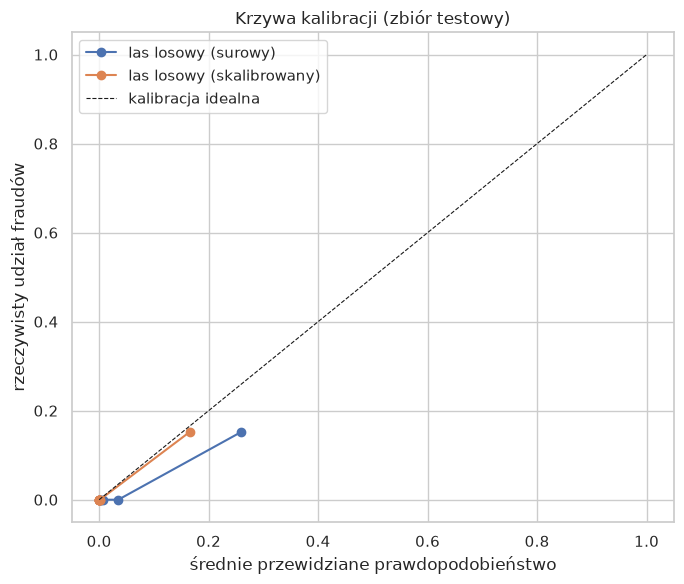

In [33]:
best_rf = searches["Las losowy"].best_estimator_

calibrated = CalibratedClassifierCV(best_rf, method="sigmoid", cv=5)
calibrated.fit(X_train, y_train)
proba_cal = calibrated.predict_proba(X_test)[:, 1]
proba_raw = probas["Las losowy (tuned)"]

print(f"Brier score przed kalibracją: {brier_score_loss(y_test, proba_raw):.5f}")
print(f"Brier score po kalibracji:    {brier_score_loss(y_test, proba_cal):.5f}")

fig, ax = plt.subplots(figsize=(7, 6))
for proba, label in [(proba_raw, "las losowy (surowy)"),
                     (proba_cal, "las losowy (skalibrowany)")]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10,
                                            strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", label=label)
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="kalibracja idealna")
ax.set_xlabel("średnie przewidziane prawdopodobieństwo")
ax.set_ylabel("rzeczywisty udział fraudów")
ax.set_title("Krzywa kalibracji (zbiór testowy)")
ax.legend()
plt.tight_layout()
plt.show()

### 6.8. Analiza kosztowa progu decyzyjnego

Próg można dobrać nie tylko pod metryki (F1), ale wprost pod **pieniądze**.
Przyjmujemy proste założenia biznesowe:

- **koszt FN** (przeoczony fraud) = średnia kwota transakcji oszukańczej
  (bank traci całą kwotę),
- **koszt FP** (fałszywy alarm) = 5 zł (koszt dodatkowej weryfikacji SMS/telefon
  i irytacji klienta).

Liczymy łączny koszt na zbiorze testowym dla każdego progu i szukamy minimum.

koszt FN (średnia kwota fraudu): 216.18 zł, koszt FP: 5.00 zł


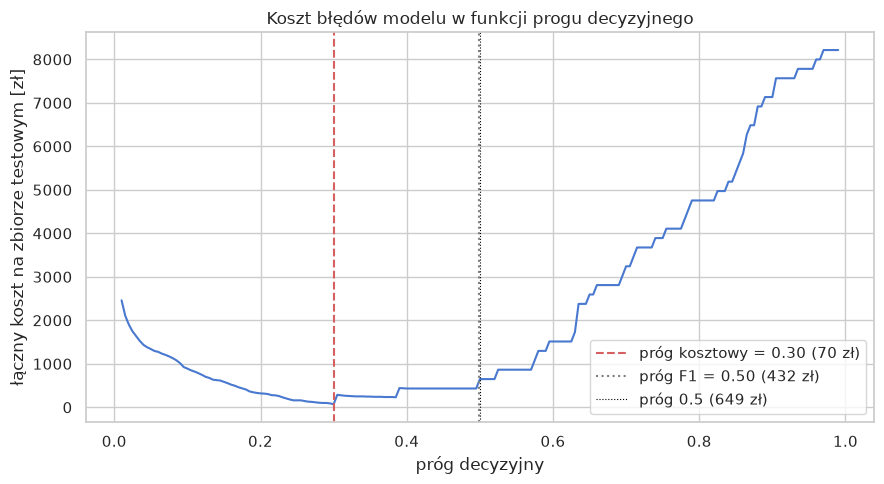

In [34]:
cost_fn = df.loc[df["is_fraud"] == 1, "amount"].mean()
cost_fp = 5.0
print(f"koszt FN (średnia kwota fraudu): {cost_fn:.2f} zł, koszt FP: {cost_fp:.2f} zł")

thresholds_grid = np.linspace(0.01, 0.99, 197)
costs = []
for t in thresholds_grid:
    pred = (best_proba >= t).astype(int)
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    costs.append(fp * cost_fp + fn * cost_fn)
costs = np.array(costs)
t_cost = thresholds_grid[np.argmin(costs)]

def total_cost(t):
    pred = (best_proba >= t).astype(int)
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    return fp * cost_fp + fn * cost_fn

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_grid, costs, color="#4878CF")
ax.axvline(t_cost, color="#D65F5F", ls="--",
           label=f"próg kosztowy = {t_cost:.2f} ({costs.min():.0f} zł)")
ax.axvline(threshold, color="gray", ls=":",
           label=f"próg F1 = {threshold:.2f} ({total_cost(threshold):.0f} zł)")
ax.axvline(0.5, color="black", ls=":", lw=0.8,
           label=f"próg 0.5 ({total_cost(0.5):.0f} zł)")
ax.set_xlabel("próg decyzyjny")
ax.set_ylabel("łączny koszt na zbiorze testowym [zł]")
ax.set_title("Koszt błędów modelu w funkcji progu decyzyjnego")
ax.legend()
plt.tight_layout()
plt.show()

Ponieważ przeoczony fraud kosztuje dziesiątki razy więcej niż fałszywy alarm,
minimum kosztowe wypada przy **niższym progu** niż optimum F1 — bardziej opłaca się
dmuchać na zimne i wysłać klientowi dodatkową weryfikację, niż przepuścić oszustwo.
To dokładnie ten kompromis, który w praktyce ustala się wspólnie z biznesem.

## 7. Wnioski końcowe

1. **DS24G2-17:** przy 1,5% fraudów kluczowa jest obsługa niezbalansowania —
   bez niej regresja logistyczna przepuszcza większość oszustw. Ważenie klas
   (`class_weight='balanced'`) daje efekt porównywalny z undersamplingiem,
   nie tracąc danych, i tę strategię przyjęliśmy.
2. **DS24G2-16:** strojenie z `GridSearchCV` (5-krotna stratyfikowana CV,
   metryka average precision) wybrało parametry potwierdzone wynikiem na
   zbiorze testowym; oba modele wyraźnie biją baseline (PR-AUC ≫ 0,015).
3. Najlepszy model wg PR-AUC z progiem maksymalizującym F1 osiąga wyniki
   bliskie ideału — to sygnał, że zbiór jest **syntetyczny** i zawiera niemal
   deterministyczną regułę fraudu; na rzeczywistych danych transakcyjnych
   należałoby oczekiwać zauważalnie niższych metryk.
4. Najsilniejsze sygnały fraudu (spójne między modelami i z EDA):
   **niezgodność lokalizacji**, **transakcja zagraniczna**, **niski trust score
   urządzenia**, **wysoka aktywność w 24 h**, **wysoka kwota**; cykliczne
   kodowanie godziny dodaje czytelny sygnał „nocności" transakcji.
5. **Rekomendacja biznesowa:** transakcje z oceną powyżej dobranego progu
   kierować do dodatkowej weryfikacji (SMS/aplikacja); próg można przesuwać
   zależnie od przepustowości zespołu antyfraudowego — kompromis pokazuje
   krzywa precision-recall.
6. **XGBoost** osiąga wyniki równorzędne z lasem losowym — na tak separowalnych
   danych oba modele drzewiaste trafiają w sufit; zostajemy przy prostszym lesie.
7. **Kalibracja (Platt/sigmoid)** poprawia wiarygodność zwracanych prawdopodobieństw
   (niższy Brier score) — istotne, gdy score ma sterować procesem biznesowym.
8. **Analiza kosztowa** (FN = średnia kwota fraudu, FP = 5 zł weryfikacji) wskazuje
   próg niższy niż optimum F1 — przy tak asymetrycznych kosztach opłaca się częściej
   alarmować; finalny próg powinien ustalić biznes na podstawie tej krzywej.
9. **Demo:** ocena pojedynczej transakcji — `python predict.py --help` oraz
   aplikacja `streamlit run app.py`.